In [6]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

data inladen + enkele waarden bekijken

In [7]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")

print(f"env data:             {df_env.shape}")
df_env.columns
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


lijst van alle variabelen

In [8]:
df_biooracle.head()

,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [9]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

kijken welke variabelen encoding nodig hebben

In [10]:
print(df_env.ClimZoneCode) 

0       SP
1       SP
2       SP
3       SP
4       SP
        ..
2447    NP
2448    NP
2449    NP
2450    NP
2451    NP
Name: ClimZoneCode, Length: 2452, dtype: object


encoding uitvoeveren en toevoegen aan dataset --> deze gebruiken in model!

In [11]:
df_env.ClimZoneCode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_env["ClimZoneCode_encoded"] = le.fit_transform(df_env["ClimZoneCode"])
df_env["ClimZoneCode_encoded"]

0       5
1       5
2       5
3       5
4       5
       ..
2447    1
2448    1
2449    1
2450    1
2451    1
Name: ClimZoneCode_encoded, Length: 2452, dtype: int32

target uitkiezen (genetische diversiteit) + variabelen in model
 --> eerst correlaties bekijken met GD, als heel lage correlatie dan niet opnemen in model

data exploratie eerst 

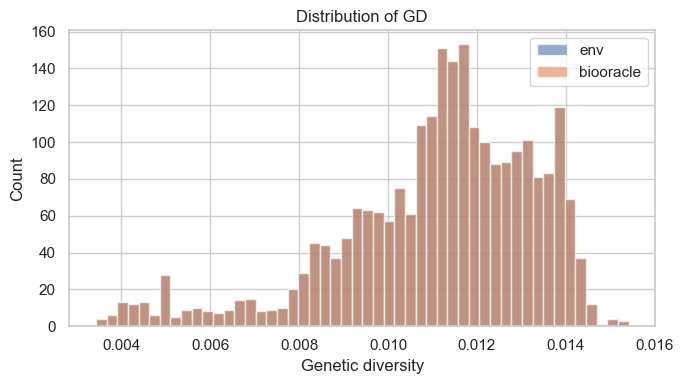

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_env["co1_genetic_diversity_mean"], bins=50, edgecolor="white", alpha=0.6, label= "env")
ax.hist(df_biooracle["co1_genetic_diversity_mean"], bins=50, edgecolor="white", alpha=0.6, label="biooracle")

ax.set_xlabel("Genetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
ax.legend()
plt.tight_layout()
plt.show()

2 datasets samenvoegen o.b.v. locatie 

In [13]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")

In [14]:
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 107)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [15]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=107)

onnodige kolommen verwijderen

In [21]:
cols_to_drop = df_merge.filter(regex=r'(?i)(min|max|range)').columns
df_merge_variables = df_merge.drop(columns=cols_to_drop)
df_merge_variables.drop(columns=["marine_species_richness_x","co1_genetic_diversity_mean_x", "PD_x", "grid_id", "long", "lat", "long_dd", "lat_dd", "ClimZoneCode", "matched_CenterLong", "matched_CenterLat", "marine_species_richness_y", "PD_y" , "MPA"], inplace=True)

In [22]:
df_merge_variables.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'SSTAnMean', 'SBTAnMean',
       'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean',
       'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary',
       'Seamount', 'ClimZoneCode_encoded', 'co1_genetic_diversity_mean_y',
       'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean',
       'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean',
       'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean',
       'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean',
       'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean',
       'terrain_characteristics_rug', 'terrain_characteristics_slope',
       'terrain_characteristics_topo', 'T_mean'],
      dtype='object')

In [23]:
print(f"data model:             {df_merge_variables.shape}")
df_merge_variables.head()

data model:             (2452, 44)


,long_deg,lat_deg,DepthMean,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,-171.74579,-71.23536,3998,-1.693377,-0.049802,33.934307,34.705566,1.153,0.708033,308.798553,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,-167.88679,-71.23536,4079,-1.697129,-0.070504,33.976231,34.703896,1.141,0.702925,309.091431,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,-164.02779,-71.23536,4185,-1.658674,-0.071121,33.934555,34.703419,1.120,0.694178,311.400299,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,-160.16879,-71.23536,4231,-1.629549,-0.072501,33.875896,34.703423,1.169,0.679715,313.670135,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,-156.30979,-71.23536,4322,-1.620574,-0.066624,33.789886,34.710335,1.094,0.683326,315.589600,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


target en variabelen selecteren

In [24]:
target = "co1_genetic_diversity_mean_y" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge_variables.columns.drop(["long_deg", "lat_deg", "co1_genetic_diversity_mean_y"]).tolist()

df = df_merge_variables[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df.shape}")
df.describe()

Shape before cleaning: (2452, 42)


,co1_genetic_diversity_mean_y,DepthMean,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,OxyBMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,16.134410,2.069516,34.374631,34.574813,4.597464,0.054981,257.412446,205.387930,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,10.626096,4.586234,1.838647,1.254989,5.905518,0.162398,54.275344,53.395459,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,-1.790485,-1.731767,4.524624,5.264678,0.096000,0.000000,196.910355,1.522620,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,6.128384,0.496306,33.835644,34.677283,1.642750,0.000000,207.841774,168.775311,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,18.972795,1.054664,34.463772,34.698887,2.995500,0.000000,236.162773,209.118347,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,26.209159,1.656099,35.316861,34.722000,5.623750,0.000000,308.180664,238.418453,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,29.790718,29.696379,38.469193,40.475456,99.214002,0.965107,394.526001,411.218811,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


missende waarden als -9999

In [25]:
df.replace(-9999.0, np.nan, inplace=True)
df.replace(-9999, np.nan, inplace=True)

missing = df.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df.shape}")

Missende waarden per kolom:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean    

data exploratie

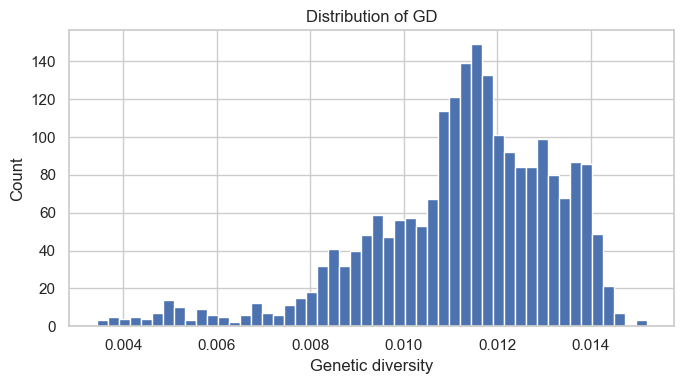

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[target], bins=50, edgecolor="white")
ax.set_xlabel("Genetic diversity")
ax.set_ylabel("Count")  
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

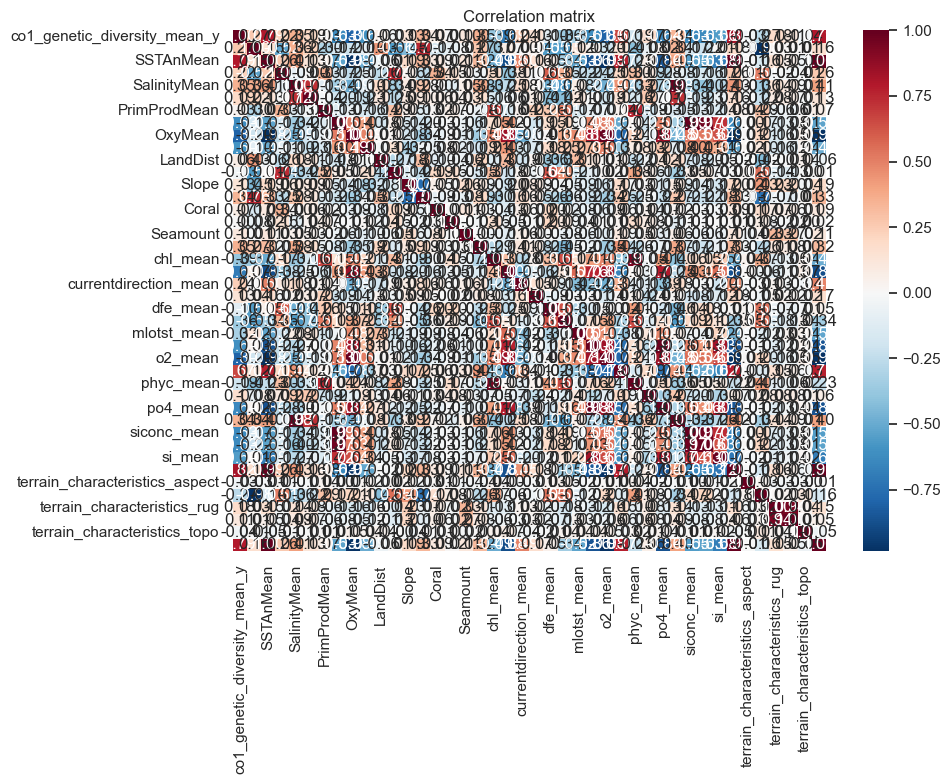

In [27]:
corr = df.corr(numeric_only = True)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "RdBu_r", center = 0, ax = ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

10 hoogste correlaties

In [31]:
corr = df.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

SSTAnMean     T_mean           0.999696
OxyMean       o2_mean          0.996980
siconc_mean   IceConAnn        0.992286
T_mean        tas_mean         0.989947
tas_mean      SSTAnMean        0.989296
o2_mean       T_mean           0.984642
              SSTAnMean        0.984581
OxyMean       SSTAnMean        0.984057
              T_mean           0.983720
SalinityMean  salinity_mean    0.982720
dtype: float64


data splitten in training en test set

In [32]:
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 1760
Test set: 441


### Fitten van een Random Forest model op training set

In [33]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1,
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=10, n_estimators=500,
                      n_jobs=1, random_state=42)

### Evalueren van rf op training en test set

moet op beide goed zijn anders is het overgefit op training set

In [34]:
y_pred = rf.predict(X_test)

r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"\nTrain-test gap: {r2_train - r2:.4f}")

Train R²: 0.9406
Test R²: 0.9138
RMSE: 0.0007
MAE: 0.0004

Train-test gap: 0.0267


### Visualiseren resultaten

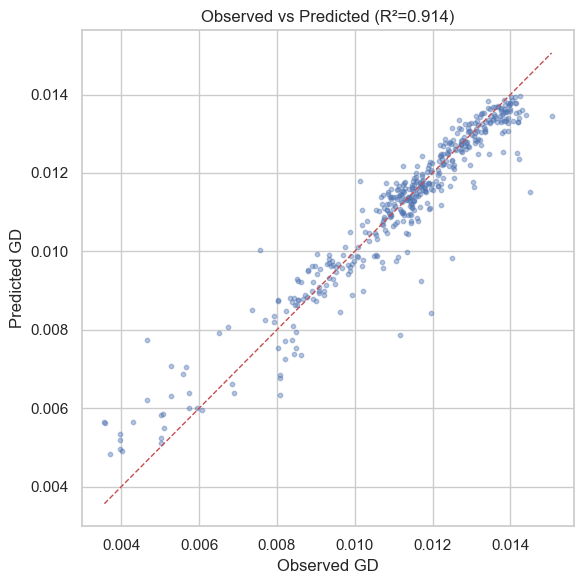

In [35]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test, y_pred, alpha=0.4, s = 10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

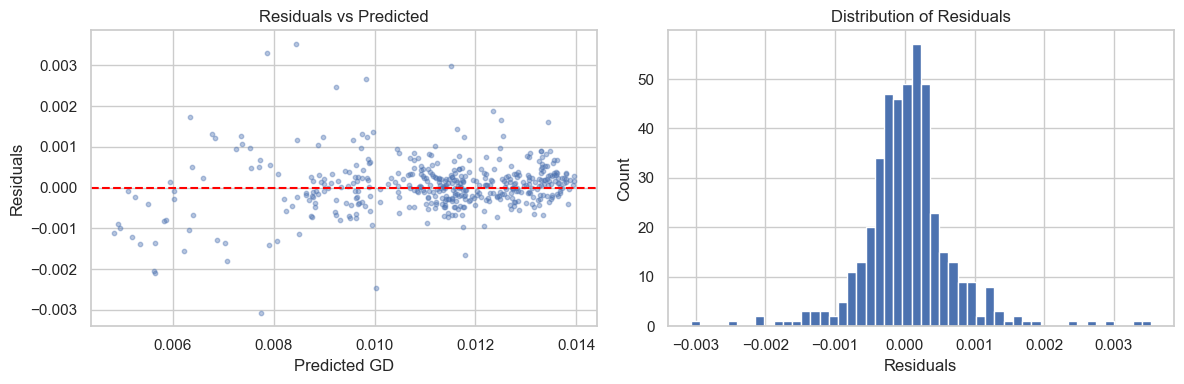

In [36]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

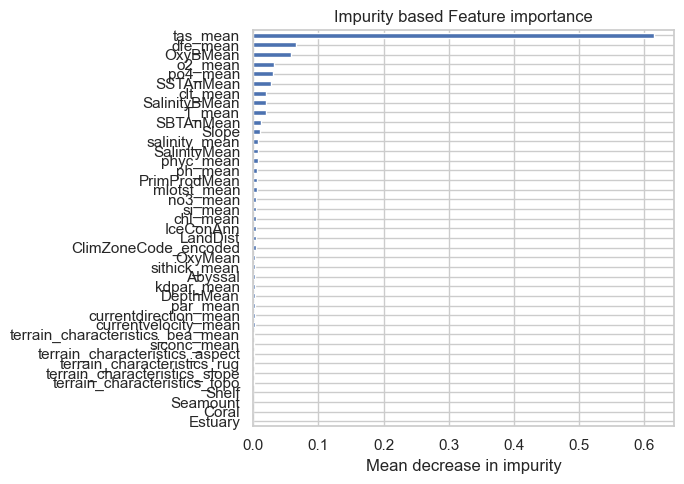

In [38]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

spatiale crossvalidatie

In [41]:
lat = df_merge_variables.loc[df.index, "lat_deg"]
lon = df_merge_variables.loc[df.index, "long_deg"]
lat_bin = pd.cut(lat, bins = np.arange(-90, 91,10), labels = False)
lon_bin = pd.cut(lon, bins = np.arange(-180, 181,10), labels = False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°x10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv = gkf, groups = spatial_blocks, scoring= "r2", n_jobs = 1,
)
print("Spatial 5 fold VC R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f} ± {spatial_cv.std():.4f}")


Spatial blocks (10°x10° grid): 422 unique blocks
Spatial 5 fold VC R² scores: [0.9095 0.8853 0.8851 0.8629 0.85  ]
Mean R²: 0.8786 ± 0.0205
